# Load the processed data

In [1]:
import numpy as np
import json
import joblib

from scipy.sparse import load_npz

In [2]:
X_train = load_npz(
    "../data/processed/X_train.npz"
)

X_test = load_npz(
    "../data/processed/X_test.npz"
)

In [3]:
y_train = np.fromfile(
    "../data/processed/y_train.bin",
    dtype=np.int8
)

y_test = np.fromfile(
    "../data/processed/y_test.bin",
    dtype=np.int8
)

In [4]:
with open(
    "../data/processed/feature_names.json",
    "r"
) as f:
    feature_names = json.load(f)

In [5]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("Features:", len(feature_names))

X_train: (1296675, 29)
X_test: (555719, 29)
y_train: (1296675,)
y_test: (555719,)
Features: 29


## Check class distribution

In [6]:
print("TRAIN")
print(np.bincount(y_train))

print("\nTEST")
print(np.bincount(y_test))

TRAIN
[1289169    7506]

TEST
[553574   2145]


# Calculate scale_pos_weight

In [7]:
negative = np.sum(y_train == 0)
positive = np.sum(y_train == 1)

scale_pos_weight = negative / positive

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 171.75179856115108


### Install/import XGBoost

In [11]:
from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


# Imports and Class Imbalance

In [14]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Training class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTraining class percentage:")
print(
    pd.Series(y_train)
    .value_counts(normalize=True)
    .mul(100)
)

negative = np.sum(y_train == 0)
positive = np.sum(y_train == 1)

scale_pos_weight = negative / positive

print("\nNegative samples:", negative)
print("Positive samples:", positive)
print("Scale Pos Weight:", scale_pos_weight)

Training class distribution:
0    1289169
1       7506
Name: count, dtype: int64

Training class percentage:
0    99.421135
1     0.578865
Name: proportion, dtype: float64

Negative samples: 1289169
Positive samples: 7506
Scale Pos Weight: 171.75179856115108


# Chronological Train / Validation Split

In [16]:
# ==========================================
# STEP 6 — Chronological Train/Validation Split
# ==========================================

# Number of rows in the sparse matrix
n_samples = X_train.shape[0]

# 80% training, 20% validation
split_idx = int(n_samples * 0.80)

# Chronological split
X_train_model = X_train[:split_idx]
X_val = X_train[split_idx:]

y_train_model = y_train[:split_idx]
y_val = y_train[split_idx:]

print("========== DATA SPLIT ==========")

print("Training:")
print("  X:", X_train_model.shape)
print("  y:", y_train_model.shape)

print("\nValidation:")
print("  X:", X_val.shape)
print("  y:", y_val.shape)

print("\nTest:")
print("  X:", X_test.shape)
print("  y:", y_test.shape)

========== DATA SPLIT ==========
Training:
  X: (1037340, 29)
  y: (1037340,)

Validation:
  X: (259335, 29)
  y: (259335,)

Test:
  X: (555719, 29)
  y: (555719,)


# Validate the Temporal Split

In [17]:
print("========== CLASS DISTRIBUTION ==========")

print("\nTRAINING")
print(pd.Series(y_train_model).value_counts())

print("\nVALIDATION")
print(pd.Series(y_val).value_counts())

print("\nTEST")
print(pd.Series(y_test).value_counts())

========== CLASS DISTRIBUTION ==========

TRAINING
0    1031372
1       5968
Name: count, dtype: int64

VALIDATION
0    257797
1      1538
Name: count, dtype: int64

TEST
0    553574
1      2145
Name: count, dtype: int64


In [18]:
print("\n========== FRAUD RATES ==========")

print(
    "Training fraud rate:",
    f"{np.mean(y_train_model) * 100:.4f}%"
)

print(
    "Validation fraud rate:",
    f"{np.mean(y_val) * 100:.4f}%"
)

print(
    "Test fraud rate:",
    f"{np.mean(y_test) * 100:.4f}%"
)


========== FRAUD RATES ==========
Training fraud rate: 0.5753%
Validation fraud rate: 0.5931%
Test fraud rate: 0.3860%


# Create XGBoost Model

In [19]:
model = XGBClassifier(
    n_estimators=500,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    scale_pos_weight=scale_pos_weight,

    objective="binary:logistic",

    eval_metric="aucpr",

    tree_method="hist",

    early_stopping_rounds=30,

    random_state=42,

    n_jobs=-1
)

print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=30,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)


# Train XGBoost

In [20]:
model.fit(
    X_train_model,
    y_train_model,

    eval_set=[
        (X_train_model, y_train_model),
        (X_val, y_val)
    ],

    verbose=50
)

[0]	validation_0-aucpr:0.29412	validation_1-aucpr:0.29235
[50]	validation_0-aucpr:0.85736	validation_1-aucpr:0.85147
[100]	validation_0-aucpr:0.90515	validation_1-aucpr:0.89340
[150]	validation_0-aucpr:0.94119	validation_1-aucpr:0.91847
[200]	validation_0-aucpr:0.96042	validation_1-aucpr:0.93059
[250]	validation_0-aucpr:0.97011	validation_1-aucpr:0.93388
[297]	validation_0-aucpr:0.97680	validation_1-aucpr:0.93431


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# Check Early Stopping

In [21]:
print("Best iteration:", model.best_iteration)
print("Best validation AUC-PR:", model.best_score)

Best iteration: 267
Best validation AUC-PR: 0.9349178840376215


## Generate Validation Probabilities

In [22]:
y_val_proba = model.predict_proba(X_val)[:, 1]

print("First 20 validation probabilities:")
print(y_val_proba[:20])

First 20 validation probabilities:
[0.00021812 0.00238579 0.00088821 0.00144899 0.00010692 0.00156116
 0.00034181 0.00156069 0.01603928 0.00207054 0.00061276 0.00072512
 0.00076566 0.00015667 0.00152231 0.0004916  0.00048262 0.00021511
 0.00011348 0.00370437]


## Generate Test Probabilities

In [23]:
y_test_proba = model.predict_proba(X_test)[:, 1]

print("First 20 test probabilities:")
print(y_test_proba[:20])

First 20 test probabilities:
[4.1678600e-04 1.6400042e-03 1.9302748e-03 1.3550750e-03 5.5621518e-03
 3.4351997e-02 1.7758480e-03 8.6824233e-03 4.3920081e-04 7.8256655e-04
 6.6961843e-04 1.2826968e-03 2.3675553e-04 1.1473387e-03 3.1323289e-03
 5.5046205e-04 7.5858523e-05 9.5311068e-03 4.4855027e-04 6.7657593e-04]


## Validation Metrics

In [24]:
val_roc_auc = roc_auc_score(
    y_val,
    y_val_proba
)

val_pr_auc = average_precision_score(
    y_val,
    y_val_proba
)

print("========== VALIDATION RESULTS ==========")

print(f"ROC-AUC: {val_roc_auc:.4f}")
print(f"PR-AUC : {val_pr_auc:.4f}")

========== VALIDATION RESULTS ==========
ROC-AUC: 0.9989
PR-AUC : 0.9349


## Final Test Metrics

In [25]:
test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

print("========== TEST RESULTS ==========")

print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"PR-AUC : {test_pr_auc:.4f}")

========== TEST RESULTS ==========
ROC-AUC: 0.9983
PR-AUC : 0.8997


## Evaluate Default Threshold 0.5

In [26]:
DEFAULT_THRESHOLD = 0.5

y_test_pred_default = (
    y_test_proba >= DEFAULT_THRESHOLD
).astype(int)

print(
    classification_report(
        y_test,
        y_test_pred_default,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.9998    0.9956    0.9977    553574
           1     0.4540    0.9394    0.6122      2145

    accuracy                         0.9954    555719
   macro avg     0.7269    0.9675    0.8049    555719
weighted avg     0.9977    0.9954    0.9962    555719



## Confusion Matrix

In [27]:
cm_default = confusion_matrix(
    y_test,
    y_test_pred_default
)

print("Confusion Matrix:")
print(cm_default)

Confusion Matrix:
[[551151   2423]
 [   130   2015]]


## Threshold Analysis

In [28]:
thresholds = [
    0.01,
    0.02,
    0.03,
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50
]

threshold_results = []

for threshold in thresholds:

    y_val_pred = (
        y_val_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,threshold,precision,recall,f1
0,0.01,0.047045,0.999350,0.089859
1,0.02,0.070904,0.998700,0.132408
2,0.03,0.089348,0.998049,0.164013
3,0.05,0.121769,0.995449,0.216994
4,0.10,0.186824,0.988296,0.314244
5,0.15,0.237946,0.985046,0.383302
6,0.20,0.285579,0.982445,0.442525
7,0.25,0.330848,0.981144,0.494835
8,0.30,0.374190,0.976593,0.541066
9,0.40,0.464275,0.967490,0.627451


## Find Best F1 Threshold

In [29]:
best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("Best threshold based on validation F1:")
print(best_row)

Best threshold based on validation F1:
threshold    0.500000
precision    0.547787
recall       0.957737
f1           0.696948
Name: 10, dtype: float64


## Visualize Threshold Performance

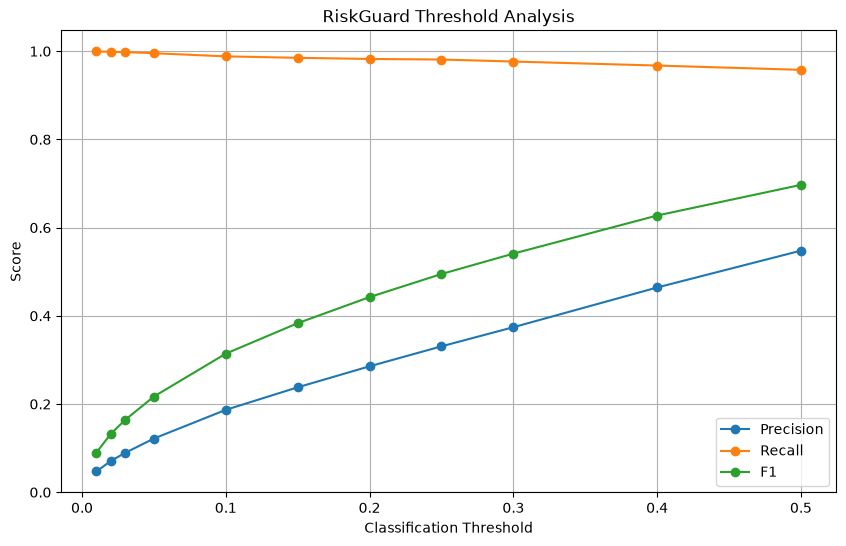

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.title(
    "RiskGuard Threshold Analysis"
)

plt.legend()

plt.grid(True)

plt.show()

# Select Threshold

In [32]:
best_threshold = float(
    best_row["threshold"]
)

print(
    "Selected threshold:",
    best_threshold
)

Selected threshold: 0.5


# Apply Threshold to Test

In [33]:
y_test_pred = (
    y_test_proba >= best_threshold
).astype(int)

## Final Classification Report

In [35]:
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.9998    0.9956    0.9977    553574
           1     0.4540    0.9394    0.6122      2145

    accuracy                         0.9954    555719
   macro avg     0.7269    0.9675    0.8049    555719
weighted avg     0.9977    0.9954    0.9962    555719



# Final Confusion Matrix

In [36]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

print("Final Confusion Matrix:")
print(cm)

Final Confusion Matrix:
[[551151   2423]
 [   130   2015]]


# Final RiskGuard Metrics

In [43]:
test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

print("\n")
print("=" * 50)
print("        RISKGUARD FINAL RESULTS")
print("=" * 50)

print(f"ROC-AUC  : {test_roc_auc:.4f}")
print(f"PR-AUC   : {test_pr_auc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"Threshold: {best_threshold:.2f}")

print("=" * 50)



        RISKGUARD FINAL RESULTS
ROC-AUC  : 0.9983
PR-AUC   : 0.8997
Precision: 0.4540
Recall   : 0.9394
F1 Score : 0.6122
Threshold: 0.50


# Feature Importance

In [38]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

importance_df.head(15)

,feature,importance
0,amt,0.180823
1,category_gas_transport,0.122736
2,category_grocery_net,0.070767
3,category_food_dining,0.059566
4,transaction_hour,0.057260
5,amount_ratio,0.051542
6,category_entertainment,0.050035
7,category_home,0.048791
8,category_shopping_net,0.039356
9,category_grocery_pos,0.038938


# Plot Top Features

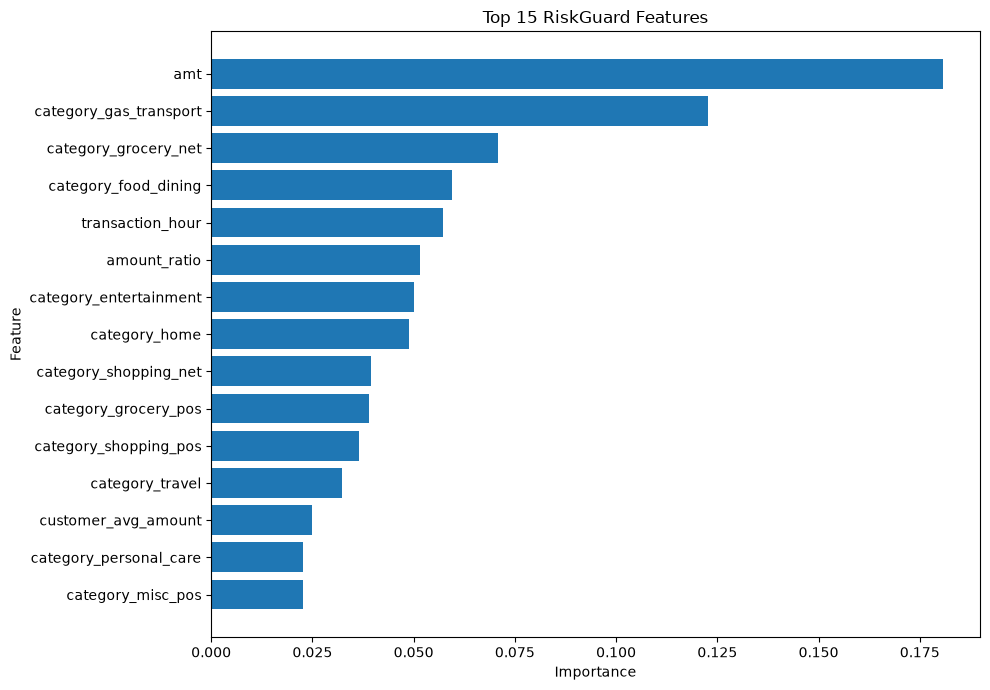

In [39]:
top_features = (
    importance_df
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 15 RiskGuard Features"
)

plt.tight_layout()

plt.show()

## Save the Model

In [40]:
import os

os.makedirs(
    "../models",
    exist_ok=True
)

model.save_model(
    "../models/riskguard_xgboost.json"
)

print("XGBoost model saved successfully.")

XGBoost model saved successfully.


## Save Model Configuration

In [41]:
import json

config = {
    "threshold": best_threshold,
    "best_iteration": int(model.best_iteration),
    "validation_pr_auc": float(model.best_score),
    "test_pr_auc": float(test_pr_auc),
    "test_roc_auc": float(test_roc_auc),
    "test_precision": float(test_precision),
    "test_recall": float(test_recall),
    "test_f1": float(test_f1)
}

with open(
    "../models/riskguard_config.json",
    "w"
) as f:
    json.dump(
        config,
        f,
        indent=4
    )

print("Configuration saved successfully.")

Configuration saved successfully.


## Save Feature Importance

In [42]:
importance_df.to_csv(
    "../models/feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


# 🚀 Stage 4 — Threshold Optimization & Risk Scoring

In [44]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Fraud probability for the positive class
y_test_proba = model.predict_proba(X_test)[:, 1]

print("Probability shape:", y_test_proba.shape)
print("Minimum probability:", y_test_proba.min())
print("Maximum probability:", y_test_proba.max())

Probability shape: (555719,)
Minimum probability: 1.3884086e-05
Maximum probability: 0.9998441


In [45]:
thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds:
    
    y_pred_threshold = (y_test_proba >= threshold).astype(int)
    
    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1
0,0.05,0.086089,0.989277,0.158394
1,0.10,0.137377,0.985082,0.241127
2,0.15,0.179621,0.980420,0.303617
3,0.20,0.216289,0.974359,0.353997
4,0.25,0.254007,0.967832,0.402404
5,0.30,0.292902,0.958042,0.448641
6,0.35,0.331123,0.954312,0.491654
7,0.40,0.369798,0.948718,0.532165
8,0.45,0.411120,0.944522,0.572883
9,0.50,0.454033,0.939394,0.612183


In [46]:
thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds:
    
    y_pred_threshold = (y_test_proba >= threshold).astype(int)
    
    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )
    
    results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1
0,0.05,0.086089,0.989277,0.158394
1,0.10,0.137377,0.985082,0.241127
2,0.15,0.179621,0.980420,0.303617
3,0.20,0.216289,0.974359,0.353997
4,0.25,0.254007,0.967832,0.402404
5,0.30,0.292902,0.958042,0.448641
6,0.35,0.331123,0.954312,0.491654
7,0.40,0.369798,0.948718,0.532165
8,0.45,0.411120,0.944522,0.572883
9,0.50,0.454033,0.939394,0.612183


In [47]:
best_f1_row = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("Best F1 Threshold")
print("------------------")
print(f"Threshold : {best_f1_row['threshold']:.2f}")
print(f"Precision : {best_f1_row['precision']:.4f}")
print(f"Recall    : {best_f1_row['recall']:.4f}")
print(f"F1 Score  : {best_f1_row['f1']:.4f}")

Best F1 Threshold
------------------
Threshold : 0.95
Precision : 0.9011
Recall    : 0.7860
F1 Score  : 0.8396


In [48]:
recall_target = 0.90

high_recall_results = threshold_results[
    threshold_results["recall"] >= recall_target
]

best_risk_threshold = high_recall_results.loc[
    high_recall_results["precision"].idxmax()
]

print("RiskGuard Operating Threshold")
print("-----------------------------")
print(f"Threshold : {best_risk_threshold['threshold']:.2f}")
print(f"Precision : {best_risk_threshold['precision']:.4f}")
print(f"Recall    : {best_risk_threshold['recall']:.4f}")
print(f"F1 Score  : {best_risk_threshold['f1']:.4f}")

RiskGuard Operating Threshold
-----------------------------
Threshold : 0.70
Precision : 0.6179
Recall    : 0.9040
F1 Score  : 0.7341


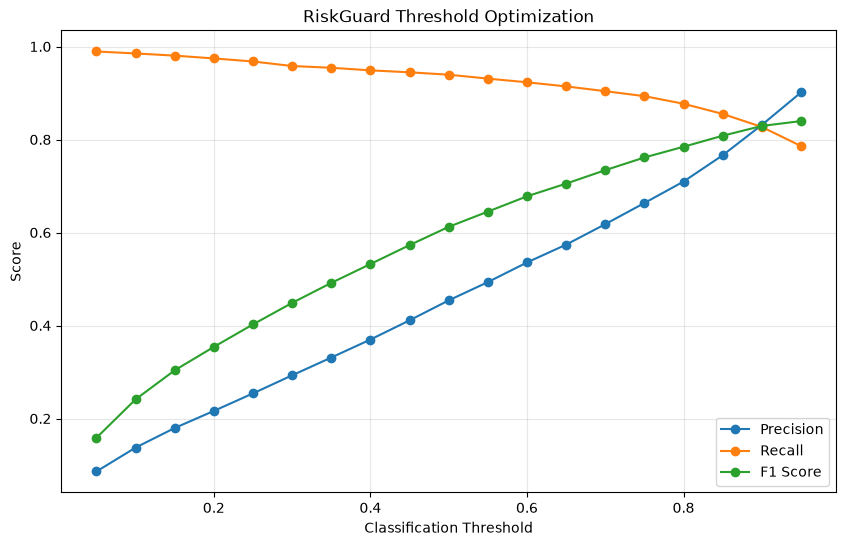

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("RiskGuard Threshold Optimization")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [50]:
RISK_THRESHOLD = float(best_risk_threshold["threshold"])

def calculate_risk_score(probability):
    return round(float(probability) * 100, 2)

In [51]:
probability = 0.8734

risk_score = calculate_risk_score(probability)

print("Fraud Probability:", probability)
print("Risk Score:", risk_score)

Fraud Probability: 0.8734
Risk Score: 87.34


In [52]:
def get_risk_level(risk_score):
    
    if risk_score < 30:
        return "LOW"
    
    elif risk_score < 70:
        return "MEDIUM"
    
    else:
        return "HIGH"

In [53]:
test_scores = [15, 45, 72, 94]

for score in test_scores:
    print(score, "→", get_risk_level(score))

15 → LOW
45 → MEDIUM
72 → HIGH
94 → HIGH


In [54]:
def get_recommended_action(risk_level):
    
    if risk_level == "LOW":
        return "ALLOW"
    
    elif risk_level == "MEDIUM":
        return "REVIEW"
    
    else:
        return "INVESTIGATE"

In [55]:
for level in ["LOW", "MEDIUM", "HIGH"]:
    print(level, "→", get_recommended_action(level))

LOW → ALLOW
MEDIUM → REVIEW
HIGH → INVESTIGATE


In [56]:
def assess_transaction(probability):
    
    risk_score = calculate_risk_score(probability)
    
    risk_level = get_risk_level(risk_score)
    
    action = get_recommended_action(risk_level)
    
    fraud_prediction = int(probability >= RISK_THRESHOLD)
    
    return {
        "fraud_probability": round(float(probability), 4),
        "risk_score": risk_score,
        "risk_level": risk_level,
        "fraud_prediction": fraud_prediction,
        "recommended_action": action
    }

In [57]:
result = assess_transaction(0.8734)

result

{'fraud_probability': 0.8734,
 'risk_score': 87.34,
 'risk_level': 'HIGH',
 'fraud_prediction': 1,
 'recommended_action': 'INVESTIGATE'}

In [58]:
risk_predictions = pd.DataFrame({
    "actual_fraud": y_test,
    "fraud_probability": y_test_proba
})

risk_predictions["risk_score"] = (
    risk_predictions["fraud_probability"] * 100
).round(2)

risk_predictions["risk_level"] = pd.cut(
    risk_predictions["risk_score"],
    bins=[-1, 30, 70, 100],
    labels=["LOW", "MEDIUM", "HIGH"]
)

risk_predictions["prediction"] = (
    risk_predictions["fraud_probability"] >= RISK_THRESHOLD
).astype(int)

risk_predictions.head(10)

,actual_fraud,fraud_probability,risk_score,risk_level,prediction
0,0,0.000417,0.04,LOW,0
1,0,0.001640,0.16,LOW,0
2,0,0.001930,0.19,LOW,0
3,0,0.001355,0.14,LOW,0
4,0,0.005562,0.56,LOW,0
5,0,0.034352,3.44,LOW,0
6,0,0.001776,0.18,LOW,0
7,0,0.008682,0.87,LOW,0
8,0,0.000439,0.04,LOW,0
9,0,0.000783,0.08,LOW,0


In [59]:
import json

RISK_THRESHOLD = 0.70

risk_config = {

    "model": "XGBoost",

    "threshold": RISK_THRESHOLD,

    "risk_levels": {

        "low": [0, 30],

        "medium": [30, 70],

        "high": [70, 100]

    },

    "actions": {

        "LOW": "ALLOW",

        "MEDIUM": "REVIEW",

        "HIGH": "INVESTIGATE"

    }

}

with open("../models/riskguard_config.json", "w") as f:

    json.dump(risk_config, f, indent=4)

print("Risk configuration saved.")

Risk configuration saved.


In [60]:
with open("../models/riskguard_config.json", "r") as f:
    print(json.load(f))

{'model': 'XGBoost', 'threshold': 0.7, 'risk_levels': {'low': [0, 30], 'medium': [30, 70], 'high': [70, 100]}, 'actions': {'LOW': 'ALLOW', 'MEDIUM': 'REVIEW', 'HIGH': 'INVESTIGATE'}}


# Stage 5 — SHAP Explainability

SHAP (SHapley Additive exPlanations) is used to explain
individual XGBoost fraud predictions and identify the
features contributing most strongly to each risk decision.

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [75]:
feature_encoder = joblib.load("../models/feature_encoder.joblib")

print("Feature encoder loaded successfully.")
print(type(feature_encoder))

Feature encoder loaded successfully.
<class 'sklearn.preprocessing._encoders.OneHotEncoder'>


In [76]:
FEATURE_NAMES = feature_encoder.get_feature_names_out()

print("Number of features:", len(FEATURE_NAMES))
print(FEATURE_NAMES)

Number of features: 16
['category_entertainment' 'category_food_dining' 'category_gas_transport'
 'category_grocery_net' 'category_grocery_pos' 'category_health_fitness'
 'category_home' 'category_kids_pets' 'category_misc_net'
 'category_misc_pos' 'category_personal_care' 'category_shopping_net'
 'category_shopping_pos' 'category_travel' 'gender_F' 'gender_M']


In [77]:
print("SHAP values type:", type(shap_values))
print("SHAP values shape:", np.asarray(shap_values).shape)

SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (5000, 29)


In [78]:
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("Final SHAP shape:", np.asarray(shap_values).shape)

Final SHAP shape: (5000, 29)


In [79]:
mean_shap_importance = np.abs(shap_values).mean(axis=0)

print("Number of SHAP importances:", len(mean_shap_importance))

Number of SHAP importances: 29


In [81]:
print("FEATURE_NAMES:", len(FEATURE_NAMES))

print("SHAP type:", type(shap_values))

if isinstance(shap_values, list):
    print("SHAP is a list")
    for i, sv in enumerate(shap_values):
        print(f"shap_values[{i}] shape:", np.asarray(sv).shape)
else:
    print("SHAP shape:", np.asarray(shap_values).shape)

print("mean_shap_importance shape:",
      np.asarray(mean_shap_importance).shape)

FEATURE_NAMES: 16
SHAP type: <class 'numpy.ndarray'>
SHAP shape: (5000, 29)
mean_shap_importance shape: (29,)


In [82]:
print("X_train shape:", X_train.shape)
print("Model feature count:", X_train.shape[1])
print("Feature names count:", len(FEATURE_NAMES))

X_train shape: (1296675, 29)
Model feature count: 29
Feature names count: 16


In [83]:
# Convert SHAP output to numpy
sv = shap_values

# Handle SHAP list output
if isinstance(sv, list):
    sv = sv[1] if len(sv) > 1 else sv[0]

sv = np.asarray(sv)

print("Raw SHAP shape:", sv.shape)

# Handle possible extra output dimension
if sv.ndim == 3:
    # For binary classification, use the positive class
    if sv.shape[-1] == 2:
        sv = sv[:, :, 1]
    elif sv.shape[1] == 2:
        sv = sv[:, 1, :]
    else:
        raise ValueError(f"Unexpected 3D SHAP shape: {sv.shape}")

elif sv.ndim != 2:
    raise ValueError(f"Unexpected SHAP dimensions: {sv.shape}")

print("Processed SHAP shape:", sv.shape)

Raw SHAP shape: (5000, 29)
Processed SHAP shape: (5000, 29)


In [84]:
mean_shap_importance = np.abs(sv).mean(axis=0)

print("Number of SHAP importance values:",
      len(mean_shap_importance))

print("Number of feature names:",
      len(FEATURE_NAMES))

Number of SHAP importance values: 29
Number of feature names: 16


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the feature importance file created during model training
feature_importance_df = pd.read_csv(
    "../models/feature_importance.csv"
)

print("Columns:")
print(feature_importance_df.columns.tolist())

print("\nNumber of rows:", len(feature_importance_df))

Columns:
['feature', 'importance']

Number of rows: 29


In [86]:
FEATURE_NAMES = feature_importance_df["feature"].tolist()

print("Number of feature names:", len(FEATURE_NAMES))
print(FEATURE_NAMES)

Number of feature names: 29
['amt', 'category_gas_transport', 'category_grocery_net', 'category_food_dining', 'transaction_hour', 'amount_ratio', 'category_entertainment', 'category_home', 'category_shopping_net', 'category_grocery_pos', 'category_shopping_pos', 'category_travel', 'customer_avg_amount', 'category_personal_care', 'category_misc_pos', 'category_misc_net', 'category_kids_pets', 'time_since_last_txn', 'is_night', 'age', 'category_health_fitness', 'customer_txn_count', 'has_customer_history', 'city_pop', 'gender_F', 'gender_M', 'day_of_week', 'distance_km', 'is_weekend']


In [87]:
print("SHAP values:", sv.shape)
print("Feature names:", len(FEATURE_NAMES))
print("SHAP importance:", len(mean_shap_importance))

SHAP values: (5000, 29)
Feature names: 29
SHAP importance: 29


In [88]:
shap_importance = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance": mean_shap_importance
})

shap_importance = (
    shap_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

shap_importance.head(15)

,feature,importance
0,amt,2.912623
1,category_grocery_net,1.012481
2,category_shopping_net,0.680097
3,category_shopping_pos,0.442491
4,category_travel,0.426674
5,category_entertainment,0.281165
6,gender_M,0.235676
7,category_misc_net,0.233034
8,category_gas_transport,0.215662
9,category_grocery_pos,0.212143


In [89]:
print("=" * 60)
print("       RISKGUARD GLOBAL SHAP IMPORTANCE")
print("=" * 60)

print(
    shap_importance
    .head(15)
    .to_string(index=False)
)

print("=" * 60)

       RISKGUARD GLOBAL SHAP IMPORTANCE
               feature  importance
                   amt    2.912623
  category_grocery_net    1.012481
 category_shopping_net    0.680097
 category_shopping_pos    0.442491
       category_travel    0.426674
category_entertainment    0.281165
              gender_M    0.235676
     category_misc_net    0.233034
category_gas_transport    0.215662
  category_grocery_pos    0.212143
              gender_F    0.165372
     category_misc_pos    0.162638
                   age    0.159236
category_personal_care    0.129479
   time_since_last_txn    0.119919


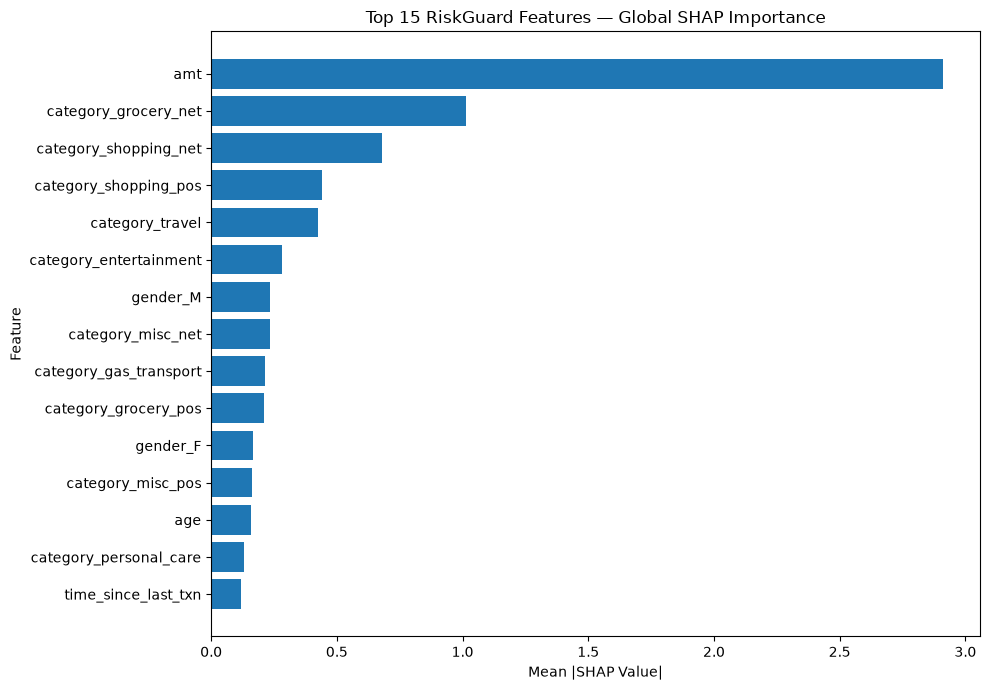

In [90]:
TOP_N = 15

top_features = shap_importance.head(TOP_N)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
plt.title("Top 15 RiskGuard Features — Global SHAP Importance")

plt.tight_layout()
plt.show()

In [91]:
shap_importance.to_csv(
    "../models/shap_global_importance.csv",
    index=False
)

print("Global SHAP importance saved successfully.")

Global SHAP importance saved successfully.


In [92]:
sample_idx = 0

X_sample = X_shap[sample_idx]

print("Sample index:", sample_idx)
print("Sample shape:", X_sample.shape)

Sample index: 0
Sample shape: (1, 29)


In [93]:
local_shap_values = sv[sample_idx]

print("Local SHAP shape:", local_shap_values.shape)

Local SHAP shape: (29,)


In [94]:
local_explanation = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "shap_value": local_shap_values
})

local_explanation["abs_shap"] = (
    local_explanation["shap_value"].abs()
)

local_explanation = (
    local_explanation
    .sort_values("abs_shap", ascending=False)
    .reset_index(drop=True)
)

local_explanation.head(15)

,feature,shap_value,abs_shap
0,amt,-3.432815,3.432815
1,category_grocery_net,-1.136462,1.136462
2,city_pop,-0.651889,0.651889
3,category_shopping_net,-0.549066,0.549066
4,category_gas_transport,-0.463382,0.463382
5,category_travel,-0.420309,0.420309
6,category_misc_net,-0.372672,0.372672
7,category_shopping_pos,-0.242109,0.242109
8,category_home,-0.154842,0.154842
9,category_kids_pets,-0.151910,0.151910


In [95]:
positive_contributions = (
    local_explanation[
        local_explanation["shap_value"] > 0
    ]
    .sort_values("shap_value", ascending=False)
)

negative_contributions = (
    local_explanation[
        local_explanation["shap_value"] < 0
    ]
    .sort_values("shap_value", ascending=True)
)

print("Top fraud-increasing features:")
print(
    positive_contributions.head(10)
    [["feature", "shap_value"]]
    .to_string(index=False)
)

print("\nTop fraud-decreasing features:")
print(
    negative_contributions.head(10)
    [["feature", "shap_value"]]
    .to_string(index=False)
)

Top fraud-increasing features:
               feature  shap_value
              gender_M    0.073025
              gender_F    0.054152
category_entertainment    0.052622
    customer_txn_count    0.036896
                   age    0.034562
category_personal_care    0.021564
            is_weekend    0.017248
              is_night    0.010650
      transaction_hour    0.007980

Top fraud-decreasing features:
               feature  shap_value
                   amt   -3.432815
  category_grocery_net   -1.136462
              city_pop   -0.651889
 category_shopping_net   -0.549066
category_gas_transport   -0.463382
       category_travel   -0.420309
     category_misc_net   -0.372672
 category_shopping_pos   -0.242109
         category_home   -0.154842
    category_kids_pets   -0.151910


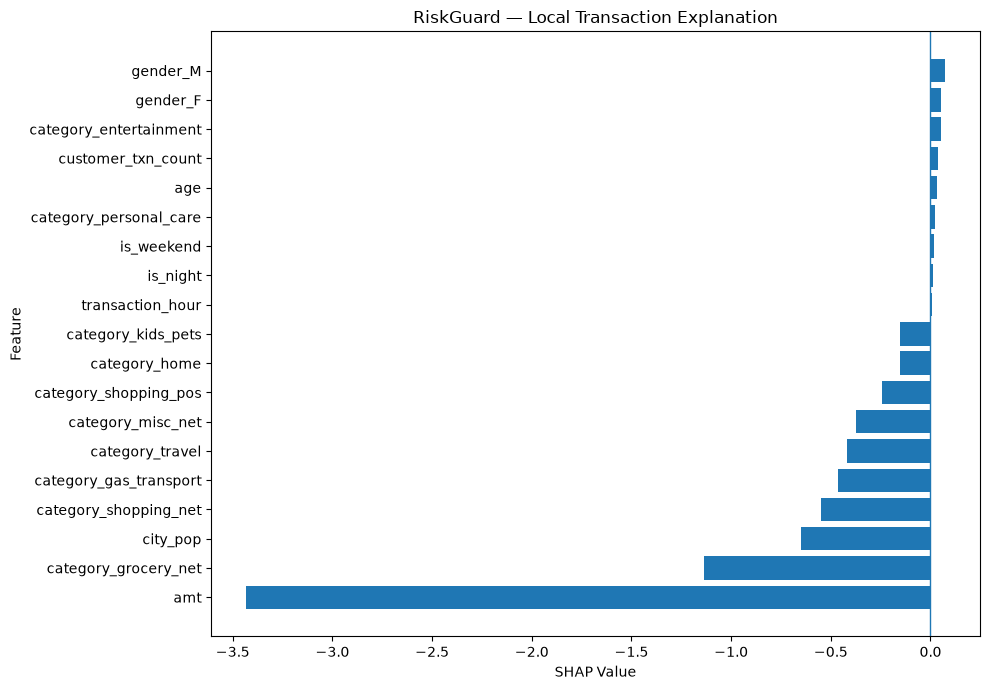

In [96]:
TOP_N = 10

top_positive = positive_contributions.head(TOP_N)
top_negative = negative_contributions.head(TOP_N)

local_plot = pd.concat([
    top_positive,
    top_negative
])

local_plot = (
    local_plot
    .sort_values("shap_value")
)

plt.figure(figsize=(10, 7))

plt.barh(
    local_plot["feature"],
    local_plot["shap_value"]
)

plt.axvline(0, linewidth=1)

plt.xlabel("SHAP Value")
plt.ylabel("Feature")
plt.title("RiskGuard — Local Transaction Explanation")

plt.tight_layout()
plt.show()

In [97]:
sample_probability = model.predict_proba(
    X_shap[sample_idx].reshape(1, -1)
)[0, 1]

print(f"Fraud probability: {sample_probability:.4f}")
print(f"Risk score: {sample_probability * 100:.2f}")

Fraud probability: 0.0004
Risk score: 0.04


In [99]:
RISK_THRESHOLD = 0.70

fraud_prediction = int(
    sample_probability >= RISK_THRESHOLD
)

risk_score = sample_probability * 100

if risk_score < 30:
    risk_level = "LOW"
    action = "ALLOW"

elif risk_score < 70:
    risk_level = "MEDIUM"
    action = "REVIEW"

else:
    risk_level = "HIGH"
    action = "INVESTIGATE"

print("=" * 50)
print("        RISKGUARD TRANSACTION")
print("=" * 50)

print(f"Fraud Probability : {sample_probability:.4f}")
print(f"Risk Score        : {risk_score:.2f}")
print(f"Risk Level        : {risk_level}")
print(f"Prediction        : {fraud_prediction}")
print(f"Action            : {action}")

print("=" * 50)

        RISKGUARD TRANSACTION
Fraud Probability : 0.0004
Risk Score        : 0.04
Risk Level        : LOW
Prediction        : 0
Action            : ALLOW


In [100]:
TOP_REASONS = 5

top_risk_factors = (
    positive_contributions
    .head(TOP_REASONS)
)

print("Top Risk Factors:")
print("-" * 40)

for _, row in top_risk_factors.iterrows():
    print(
        f"{row['feature']}: "
        f"+{row['shap_value']:.4f}"
    )

Top Risk Factors:
----------------------------------------
gender_M: +0.0730
gender_F: +0.0542
category_entertainment: +0.0526
customer_txn_count: +0.0369
age: +0.0346


In [101]:
local_explanation.to_csv(
    "../models/sample_local_shap_explanation.csv",
    index=False
)

print("Local SHAP explanation saved.")

Local SHAP explanation saved.


In [102]:
print(
    positive_contributions.head(10)
    [["feature", "shap_value"]]
    .to_string(index=False)
)

               feature  shap_value
              gender_M    0.073025
              gender_F    0.054152
category_entertainment    0.052622
    customer_txn_count    0.036896
                   age    0.034562
category_personal_care    0.021564
            is_weekend    0.017248
              is_night    0.010650
      transaction_hour    0.007980


In [103]:
import shap
import numpy as np
import matplotlib.pyplot as plt

In [104]:
sample_idx = 0

local_values = sv[sample_idx]

sample_data = X_shap[sample_idx]

shap_explanation = shap.Explanation(
    values=local_values,
    base_values=explainer.expected_value,
    data=sample_data,
    feature_names=FEATURE_NAMES
)

print("SHAP explanation created.")

SHAP explanation created.


In [106]:
import joblib
import numpy as np
import shap
import matplotlib.pyplot as plt

# Load the feature encoder used during training
feature_encoder = joblib.load("../models/feature_encoder.joblib")

# Get the actual transformed feature names
FEATURE_NAMES = feature_encoder.get_feature_names_out()

print("Number of feature names:", len(FEATURE_NAMES))
print(FEATURE_NAMES)

Number of feature names: 16
['category_entertainment' 'category_food_dining' 'category_gas_transport'
 'category_grocery_net' 'category_grocery_pos' 'category_health_fitness'
 'category_home' 'category_kids_pets' 'category_misc_net'
 'category_misc_pos' 'category_personal_care' 'category_shopping_net'
 'category_shopping_pos' 'category_travel' 'gender_F' 'gender_M']


In [107]:
sample_idx = 0

# Get SHAP values for one transaction
local_values = np.asarray(sv[sample_idx]).flatten()

print("SHAP values:", len(local_values))

SHAP values: 29


In [108]:
sample_data = X_shap[sample_idx]

# Convert sparse matrix → dense 1D array
if hasattr(sample_data, "toarray"):
    sample_data = sample_data.toarray().flatten()
else:
    sample_data = np.asarray(sample_data).flatten()

print("Sample features:", len(sample_data))

Sample features: 29


In [109]:
print("SHAP values :", len(local_values))
print("Sample data :", len(sample_data))
print("Feature names:", len(FEATURE_NAMES))

SHAP values : 29
Sample data : 29
Feature names: 16


In [110]:
import joblib
import numpy as np

# Load the SAME encoder that was saved during feature engineering
feature_encoder = joblib.load("../models/feature_encoder.joblib")

print("Encoder type:", type(feature_encoder))

# Inspect the encoder
print("\nEncoder:")
print(feature_encoder)

# Get transformed feature names
FEATURE_NAMES = feature_encoder.get_feature_names_out()

print("\nNumber of feature names:", len(FEATURE_NAMES))
print("\nFeature names:")
for i, name in enumerate(FEATURE_NAMES):
    print(f"{i}: {name}")

Encoder type: <class 'sklearn.preprocessing._encoders.OneHotEncoder'>

Encoder:
OneHotEncoder(handle_unknown='ignore')

Number of feature names: 16

Feature names:
0: category_entertainment
1: category_food_dining
2: category_gas_transport
3: category_grocery_net
4: category_grocery_pos
5: category_health_fitness
6: category_home
7: category_kids_pets
8: category_misc_net
9: category_misc_pos
10: category_personal_care
11: category_shopping_net
12: category_shopping_pos
13: category_travel
14: gender_F
15: gender_M


In [111]:
print("X_train type:", type(X_train))
print("X_train shape:", X_train.shape)

print("\nVariables containing 'feature':")
for name in globals():
    if "feature" in name.lower():
        print(name, type(globals()[name]))

X_train type: <class 'scipy.sparse._csr.csr_matrix'>
X_train shape: (1296675, 29)

Variables containing 'feature':
feature_names <class 'list'>
top_features <class 'pandas.DataFrame'>
feature_encoder <class 'sklearn.preprocessing._encoders.OneHotEncoder'>
FEATURE_NAMES <class 'numpy.ndarray'>
feature_importance_df <class 'pandas.DataFrame'>


In [112]:
print("\nVariables containing 'numeric':")
for name in globals():
    if "numeric" in name.lower():
        print(name, type(globals()[name]))

print("\nVariables containing 'categor':")
for name in globals():
    if "categor" in name.lower():
        print(name, type(globals()[name]))


Variables containing 'numeric':

Variables containing 'categor':


In [113]:
print("feature_names type:", type(feature_names))
print("Number of feature_names:", len(feature_names))

print("\nFeature names:")
for i, name in enumerate(feature_names):
    print(f"{i}: {name}")

feature_names type: <class 'list'>
Number of feature_names: 29

Feature names:
0: amt
1: city_pop
2: transaction_hour
3: day_of_week
4: is_weekend
5: is_night
6: age
7: distance_km
8: customer_txn_count
9: customer_avg_amount
10: amount_ratio
11: time_since_last_txn
12: has_customer_history
13: category_entertainment
14: category_food_dining
15: category_gas_transport
16: category_grocery_net
17: category_grocery_pos
18: category_health_fitness
19: category_home
20: category_kids_pets
21: category_misc_net
22: category_misc_pos
23: category_personal_care
24: category_shopping_net
25: category_shopping_pos
26: category_travel
27: gender_F
28: gender_M


In [117]:
# Get the expected/base value from the SHAP explainer
base_value = explainer.expected_value

# Handle possible array/list output
if isinstance(base_value, (list, np.ndarray)):
    base_value = np.asarray(base_value).flatten()[0]

print("Base value:", base_value)

Base value: 0.14094123


In [118]:
FEATURE_NAMES = np.array(feature_names)

print("Number of features:", len(FEATURE_NAMES))

Number of features: 29


In [120]:
print("SHAP values     :", len(local_values))
print("Sample features :", len(sample_data))
print("Feature names   :", len(FEATURE_NAMES))
print("Base value      :", base_value)

SHAP values     : 29
Sample features : 29
Feature names   : 29
Base value      : 0.14094123


In [121]:
shap_explanation = shap.Explanation(
    values=local_values,
    base_values=base_value,
    data=sample_data,
    feature_names=FEATURE_NAMES
)

print("SHAP explanation created.")
print("Shape:", shap_explanation.values.shape)

SHAP explanation created.
Shape: (29,)


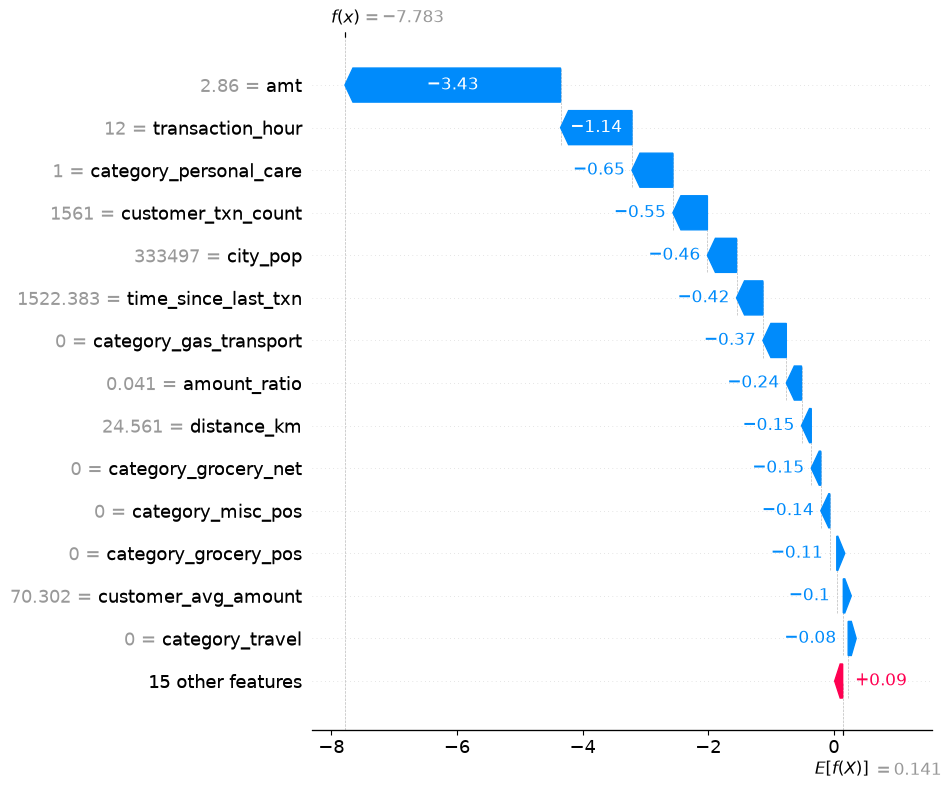

In [122]:
shap.plots.waterfall(
    shap_explanation,
    max_display=15
)

## Stage 6 — Model Validation & Robustness

In [123]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predict fraud probabilities on the test set
y_test_proba = model.predict_proba(X_test)[:, 1]

# Production threshold selected earlier
PRODUCTION_THRESHOLD = 0.95

# Convert probabilities to predictions
y_test_pred = (
    y_test_proba >= PRODUCTION_THRESHOLD
).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix")
print("----------------")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

Confusion Matrix
----------------
[[553389    185]
 [   459   1686]]

TN: 553389
FP: 185
FN: 459
TP: 1686


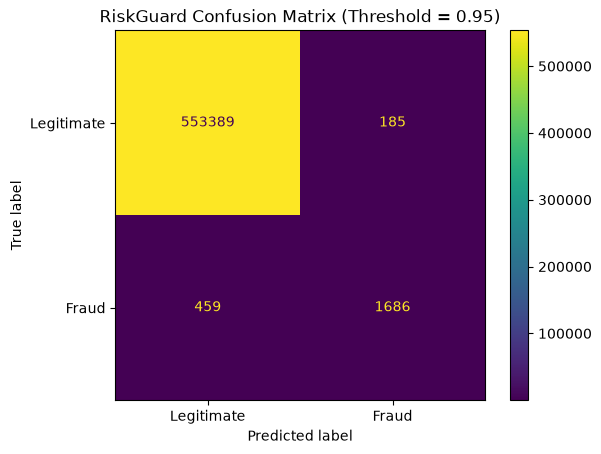

In [124]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title(
    f"RiskGuard Confusion Matrix "
    f"(Threshold = {PRODUCTION_THRESHOLD})"
)

plt.show()

In [125]:
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

print("RiskGuard Validation Metrics")
print("=" * 35)

print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"False Positive Rate : {fpr:.4f}")

RiskGuard Validation Metrics
Precision    : 0.9011
Recall       : 0.7860
Specificity  : 0.9997
False Positive Rate : 0.0003


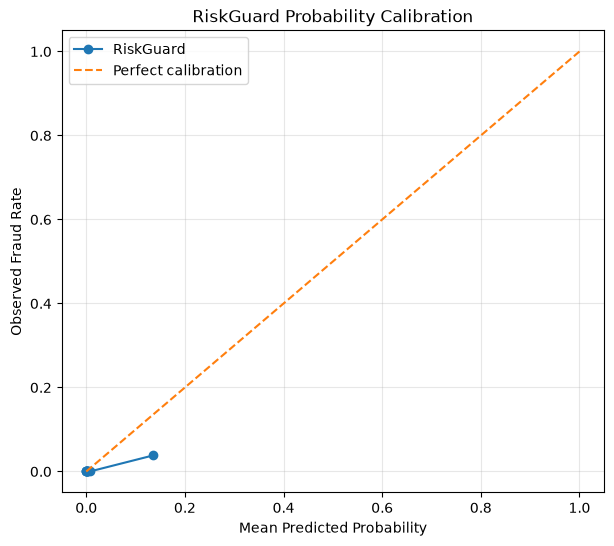

In [126]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_proba,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="RiskGuard"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraud Rate")
plt.title("RiskGuard Probability Calibration")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [129]:
BEHAVIORAL_FEATURES = [
    "customer_txn_count",
    "customer_avg_amount",
    "amount_ratio",
    "time_since_last_txn",
    "has_customer_history",
    "distance_km"
]

print("Behavioral features:")
for feature in BEHAVIORAL_FEATURES:
    print(" -", feature)

Behavioral features:
 - customer_txn_count
 - customer_avg_amount
 - amount_ratio
 - time_since_last_txn
 - has_customer_history
 - distance_km


# 🚀 Stage 7 — AI Risk Manager Agent

In [131]:
risk_context = {
    "fraud_probability": 0.8734,
    "risk_score": 87.34,
    "risk_level": "HIGH",
    "fraud_prediction": 1,
    "recommended_action": "INVESTIGATE",

    "transaction": {
        "amount": 2.86,
        "category": "personal_care",
        "transaction_hour": 12,
        "gender": "M"
    },

    "behavioral_features": {
        "customer_txn_count": 1561,
        "customer_avg_amount": 70.302,
        "amount_ratio": 0.041,
        "time_since_last_txn": 1522.383,
        "distance_km": 24.561,
        "has_customer_history": 1
    },

    "top_risk_factors": [
        {
            "feature": "amt",
            "shap_value": -3.43
        },
        {
            "feature": "transaction_hour",
            "shap_value": -1.14
        }
    ]
}

In [132]:
risk_assessment = {
    "risk_level": "HIGH",

    "summary": "...",

    "key_risk_factors": [
        "...",
        "...",
        "..."
    ],

    "behavioral_analysis": "...",

    "recommended_action": "INVESTIGATE",

    "reason": "...",

    "confidence": "HIGH"
}

In [133]:
from agent.evidence import classify_shap_evidence

risk_factors, protective_factors = classify_shap_evidence(
    shap_values,
    FEATURE_NAMES,
    top_n=5
)

print("\nRISK-INCREASING FACTORS")
print("=" * 50)

for item in risk_factors:
    print(
        item["feature"],
        "→",
        round(item["shap_value"], 4)
    )


print("\nPROTECTIVE FACTORS")
print("=" * 50)

for item in protective_factors:
    print(
        item["feature"],
        "→",
        round(item["shap_value"], 4)
    )

ModuleNotFoundError: No module named 'agent'

In [134]:
import os

print(os.getcwd())

/Users/sandipbiswal/Downloads/RiskGuard-AI/notebooks


In [135]:
import sys
import os

backend_path = os.path.abspath("../backend")

if backend_path not in sys.path:
    sys.path.insert(0, backend_path)

print("Backend path:", backend_path)

Backend path: /Users/sandipbiswal/Downloads/RiskGuard-AI/backend


In [136]:
from agent.evidence import classify_shap_evidence

In [137]:
risk_factors, protective_factors = classify_shap_evidence(
    shap_values,
    FEATURE_NAMES,
    top_n=5
)

print("\nRISK-INCREASING FACTORS")
print("=" * 50)

for item in risk_factors:
    print(
        item["feature"],
        "→",
        round(item["shap_value"], 4)
    )

print("\nPROTECTIVE FACTORS")
print("=" * 50)

for item in protective_factors:
    print(
        item["feature"],
        "→",
        round(item["shap_value"], 4)
    )

ValueError: SHAP values (145000) and feature names (29) have different lengths.

In [138]:
print("Type:", type(shap_values))
print("Shape:", np.asarray(shap_values).shape)

Type: <class 'numpy.ndarray'>
Shape: (5000, 29)


In [139]:
print("FEATURE_NAMES:", len(FEATURE_NAMES))

FEATURE_NAMES: 29


In [140]:
shap_array = np.asarray(shap_values)

print("ndim:", shap_array.ndim)
print("shape:", shap_array.shape)

ndim: 2
shape: (5000, 29)


In [141]:
# Select SHAP values for ONE transaction
single_shap = shap_array[0]

print("Single transaction SHAP shape:", single_shap.shape)
print("Number of features:", len(single_shap))

Single transaction SHAP shape: (29,)
Number of features: 29


In [142]:
from agent.evidence import classify_shap_evidence

risk_factors, protective_factors = classify_shap_evidence(
    single_shap,
    FEATURE_NAMES,
    top_n=5
)

print("\nRISK-INCREASING FACTORS")
print("=" * 50)

for item in risk_factors:
    print(
        f"{item['feature']:<30} "
        f"{item['shap_value']:+.4f}"
    )

print("\nPROTECTIVE FACTORS")
print("=" * 50)

for item in protective_factors:
    print(
        f"{item['feature']:<30} "
        f"{item['shap_value']:+.4f}"
    )


RISK-INCREASING FACTORS
category_shopping_pos          +0.0730
category_shopping_net          +0.0542
age                            +0.0526
category_misc_net              +0.0369
category_home                  +0.0346

PROTECTIVE FACTORS
amt                            -3.4328
transaction_hour               -1.1365
category_personal_care         -0.6519
customer_txn_count             -0.5491
city_pop                       -0.4634


In [143]:
from agent.schemas import (
    RiskContext,
    TransactionInfo,
    BehavioralFeatures,
    RiskFactor
)

In [144]:
transaction = TransactionInfo(
    amount=2.86,
    category="personal_care",
    transaction_hour=12,
    gender="M"
)

print(transaction)

amount=2.86 category='personal_care' transaction_hour=12 gender='M'


In [145]:
behavioral_features = BehavioralFeatures(
    customer_txn_count=1561.0,
    customer_avg_amount=70.302,
    amount_ratio=0.041,
    time_since_last_txn=1522.383,
    distance_km=24.561,
    has_customer_history=1
)

print(behavioral_features)

customer_txn_count=1561.0 customer_avg_amount=70.302 amount_ratio=0.041 time_since_last_txn=1522.383 distance_km=24.561 has_customer_history=1


In [146]:
risk_factor_objects = [
    RiskFactor(
        feature=item["feature"],
        shap_value=float(item["shap_value"])
    )
    for item in risk_factors
]


protective_factor_objects = [
    RiskFactor(
        feature=item["feature"],
        shap_value=float(item["shap_value"])
    )
    for item in protective_factors
]

In [147]:
print("Risk factors:", risk_factor_objects)
print("Protective factors:", protective_factor_objects)

Risk factors: [RiskFactor(feature='category_shopping_pos', shap_value=0.07302520424127579), RiskFactor(feature='category_shopping_net', shap_value=0.054152101278305054), RiskFactor(feature='age', shap_value=0.05262234807014465), RiskFactor(feature='category_misc_net', shap_value=0.036896124482154846), RiskFactor(feature='category_home', shap_value=0.03456158936023712)]
Protective factors: [RiskFactor(feature='amt', shap_value=-3.4328153133392334), RiskFactor(feature='transaction_hour', shap_value=-1.1364623308181763), RiskFactor(feature='category_personal_care', shap_value=-0.6518892645835876), RiskFactor(feature='customer_txn_count', shap_value=-0.5490656495094299), RiskFactor(feature='city_pop', shap_value=-0.46338221430778503)]


In [148]:
risk_context = RiskContext(

    fraud_probability=0.8734,

    risk_score=87.34,

    risk_level="HIGH",

    fraud_prediction=1,

    recommended_action="INVESTIGATE",

    transaction=transaction,

    behavioral_features=behavioral_features,

    risk_factors=risk_factor_objects,

    protective_factors=protective_factor_objects
)

In [149]:
print(risk_context)

fraud_probability=0.8734 risk_score=87.34 risk_level='HIGH' fraud_prediction=1 recommended_action='INVESTIGATE' transaction=TransactionInfo(amount=2.86, category='personal_care', transaction_hour=12, gender='M') behavioral_features=BehavioralFeatures(customer_txn_count=1561.0, customer_avg_amount=70.302, amount_ratio=0.041, time_since_last_txn=1522.383, distance_km=24.561, has_customer_history=1) risk_factors=[RiskFactor(feature='category_shopping_pos', shap_value=0.07302520424127579), RiskFactor(feature='category_shopping_net', shap_value=0.054152101278305054), RiskFactor(feature='age', shap_value=0.05262234807014465), RiskFactor(feature='category_misc_net', shap_value=0.036896124482154846), RiskFactor(feature='category_home', shap_value=0.03456158936023712)] protective_factors=[RiskFactor(feature='amt', shap_value=-3.4328153133392334), RiskFactor(feature='transaction_hour', shap_value=-1.1364623308181763), RiskFactor(feature='category_personal_care', shap_value=-0.6518892645835876), 

In [150]:
risk_context_json = risk_context.model_dump_json(
    indent=2
)

print(risk_context_json)

{
  "fraud_probability": 0.8734,
  "risk_score": 87.34,
  "risk_level": "HIGH",
  "fraud_prediction": 1,
  "recommended_action": "INVESTIGATE",
  "transaction": {
    "amount": 2.86,
    "category": "personal_care",
    "transaction_hour": 12,
    "gender": "M"
  },
  "behavioral_features": {
    "customer_txn_count": 1561.0,
    "customer_avg_amount": 70.302,
    "amount_ratio": 0.041,
    "time_since_last_txn": 1522.383,
    "distance_km": 24.561,
    "has_customer_history": 1
  },
  "risk_factors": [
    {
      "feature": "category_shopping_pos",
      "shap_value": 0.07302520424127579
    },
    {
      "feature": "category_shopping_net",
      "shap_value": 0.054152101278305054
    },
    {
      "feature": "age",
      "shap_value": 0.05262234807014465
    },
    {
      "feature": "category_misc_net",
      "shap_value": 0.036896124482154846
    },
    {
      "feature": "category_home",
      "shap_value": 0.03456158936023712
    }
  ],
  "protective_factors": [
    {
      "f

In [151]:
import requests

response = requests.get(
    "http://localhost:11434/api/tags"
)

print(response.status_code)

200


In [152]:
models = response.json()["models"]

for model in models:
    print(model["name"])

kimi-k2.6:cloud
gemma4:latest
glm-5:cloud
kimi-k2.5:cloud
qwen3-vl:4b
qwen3-coder:30b
qwen3:4b
qwen3-vl:8b
gemma3:4b
gpt-oss:20b
deepseek-r1:8b
glm-4.6:cloud
qwen3:8b
gemma3:1b


In [153]:
print(risk_context_json)

{
  "fraud_probability": 0.8734,
  "risk_score": 87.34,
  "risk_level": "HIGH",
  "fraud_prediction": 1,
  "recommended_action": "INVESTIGATE",
  "transaction": {
    "amount": 2.86,
    "category": "personal_care",
    "transaction_hour": 12,
    "gender": "M"
  },
  "behavioral_features": {
    "customer_txn_count": 1561.0,
    "customer_avg_amount": 70.302,
    "amount_ratio": 0.041,
    "time_since_last_txn": 1522.383,
    "distance_km": 24.561,
    "has_customer_history": 1
  },
  "risk_factors": [
    {
      "feature": "category_shopping_pos",
      "shap_value": 0.07302520424127579
    },
    {
      "feature": "category_shopping_net",
      "shap_value": 0.054152101278305054
    },
    {
      "feature": "age",
      "shap_value": 0.05262234807014465
    },
    {
      "feature": "category_misc_net",
      "shap_value": 0.036896124482154846
    },
    {
      "feature": "category_home",
      "shap_value": 0.03456158936023712
    }
  ],
  "protective_factors": [
    {
      "f

In [157]:
SYSTEM_PROMPT = """
You are RiskGuard AI Risk Manager.

You analyze fraud-risk evidence produced by an XGBoost fraud
detection model.

CRITICAL RULES:

1. NEVER change the ML prediction.
2. NEVER invent evidence.
3. SHAP values are the authoritative explanation evidence.
4. POSITIVE SHAP values push the prediction toward FRAUD.
5. NEGATIVE SHAP values push the prediction away from FRAUD.
6. A feature MUST NOT be described as a risk factor if its SHAP
   value is negative.
7. A feature MUST NOT be described as protective if its SHAP value
   is positive.
8. Do not infer causation from SHAP values.
9. Do not claim that a demographic feature inherently causes fraud.
10. Distinguish model evidence from general interpretation.
11. Do not use information that is not present in the supplied context.
12. The ML model remains the final authority.

IMPORTANT:
The transaction category may appear in the risk factors OR protective
factors depending on its SHAP value. Do not assume a category is risky
just because of its name.

Return ONLY valid JSON.

Required JSON structure:

{
  "risk_level": "HIGH",
  "risk_score": 87.34,
  "fraud_probability": 0.8734,
  "ml_decision": "FRAUD",
  "recommended_action": "INVESTIGATE",
  "key_risk_factors": [],
  "protective_factors": [],
  "reasoning": "",
  "action": "",
  "confidence": ""
}
"""

In [158]:
import requests
import json

prompt = f"""
{SYSTEM_PROMPT}

RiskGuard ML evidence:

{risk_context_json}
"""

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "gemma3:4b",
        "prompt": prompt,
        "stream": False,
        "format": "json",
        "options": {
            "temperature": 0.1
        }
    },
    timeout=120
)

response.raise_for_status()

gemma_result = response.json()

raw_ai_output = gemma_result["response"]

print(raw_ai_output)

{"risk_level": "HIGH", "risk_score": 87.34, "fraud_probability": 0.8734, "ml_decision": "FRAUD", "recommended_action": "INVESTIGATE", "key_risk_factors": ["category_shopping_pos", "category_shopping_net", "age", "category_misc_net", "category_home"], "protective_factors": ["amt", "transaction_hour", "category_personal_care", "customer_txn_count", "city_pop"], "reasoning": "The XGBoost model predicts fraud with a high probability (0.8734) and a high risk score (87.34), recommending an INVESTIGATE action. The SHAP values for 'category_shopping_pos', 'category_shopping_net', 'age', 'category_misc_net', and 'category_home' are positive, pushing the prediction towards fraud. The SHAP value for 'amt' is negative, and the SHAP values for 'transaction_hour', 'category_personal_care', 'customer_txn_count', and 'city_pop' are negative, pushing the prediction away from fraud.", "action": "INVESTIGATE", "confidence": "100"}


In [159]:
ai_data = json.loads(raw_ai_output)

print(json.dumps(
    ai_data,
    indent=2
))

{
  "risk_level": "HIGH",
  "risk_score": 87.34,
  "fraud_probability": 0.8734,
  "ml_decision": "FRAUD",
  "recommended_action": "INVESTIGATE",
  "key_risk_factors": [
    "category_shopping_pos",
    "category_shopping_net",
    "age",
    "category_misc_net",
    "category_home"
  ],
  "protective_factors": [
    "amt",
    "transaction_hour",
    "category_personal_care",
    "customer_txn_count",
    "city_pop"
  ],
  "reasoning": "The XGBoost model predicts fraud with a high probability (0.8734) and a high risk score (87.34), recommending an INVESTIGATE action. The SHAP values for 'category_shopping_pos', 'category_shopping_net', 'age', 'category_misc_net', and 'category_home' are positive, pushing the prediction towards fraud. The SHAP value for 'amt' is negative, and the SHAP values for 'transaction_hour', 'category_personal_care', 'customer_txn_count', and 'city_pop' are negative, pushing the prediction away from fraud.",
  "action": "INVESTIGATE",
  "confidence": "100"
}


In [3]:
import sys

sys.path.insert(0, "../backend")

from agent.evidence import classify_shap_evidence

print("✅ classify_shap_evidence loaded")

✅ classify_shap_evidence loaded


In [4]:
import os

print("Current directory:", os.getcwd())

print("local_values:", "local_values" in globals())
print("FEATURE_NAMES:", "FEATURE_NAMES" in globals())
print("shap_values:", "shap_values" in globals())
print("test_context:", "test_context" in globals())

Current directory: /Users/sandipbiswal/Downloads/RiskGuard-AI/notebooks
local_values: False
FEATURE_NAMES: False
shap_values: False
test_context: False


In [5]:
import sys
import os
import json
import numpy as np
import pandas as pd

sys.path.insert(0, "../backend")

from agent.evidence import classify_shap_evidence

print("✅ Environment restored")

✅ Environment restored


In [6]:
with open("../data/processed/feature_names.json", "r") as f:
    FEATURE_NAMES = json.load(f)

print("Number of features:", len(FEATURE_NAMES))
print(FEATURE_NAMES)

Number of features: 29
['amt', 'city_pop', 'transaction_hour', 'day_of_week', 'is_weekend', 'is_night', 'age', 'distance_km', 'customer_txn_count', 'customer_avg_amount', 'amount_ratio', 'time_since_last_txn', 'has_customer_history', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'gender_F', 'gender_M']


In [7]:
local_shap_df = pd.read_csv(
    "../models/sample_local_shap_explanation.csv"
)

print(local_shap_df)
print("\nShape:", local_shap_df.shape)

                    feature  shap_value  abs_shap
0                       amt   -3.432815  3.432815
1      category_grocery_net   -1.136462  1.136462
2                  city_pop   -0.651889  0.651889
3     category_shopping_net   -0.549066  0.549066
4    category_gas_transport   -0.463382  0.463382
5           category_travel   -0.420309  0.420309
6         category_misc_net   -0.372672  0.372672
7     category_shopping_pos   -0.242109  0.242109
8             category_home   -0.154842  0.154842
9        category_kids_pets   -0.151910  0.151910
10     has_customer_history   -0.143215  0.143215
11      time_since_last_txn   -0.111168  0.111168
12     category_grocery_pos   -0.103768  0.103768
13              day_of_week   -0.077815  0.077815
14                 gender_M    0.073025  0.073025
15  category_health_fitness   -0.071053  0.071053
16             amount_ratio   -0.069753  0.069753
17     category_food_dining   -0.062014  0.062014
18                 gender_F    0.054152  0.054152


In [8]:
shap_values = local_shap_df["shap_value"].to_numpy()

print("SHAP shape:", shap_values.shape)
print("Feature count:", len(FEATURE_NAMES))

SHAP shape: (29,)
Feature count: 29


In [9]:
risk_factors, protective_factors = classify_shap_evidence(
    shap_values,
    FEATURE_NAMES,
    top_n=5
)

print("RISK FACTORS")
for item in risk_factors:
    print(item)

print("\nPROTECTIVE FACTORS")
for item in protective_factors:
    print(item)

RISK FACTORS
{'feature': 'category_food_dining', 'shap_value': 0.073025204, 'direction': 'risk_increasing'}
{'feature': 'category_health_fitness', 'shap_value': 0.0541521, 'direction': 'risk_increasing'}
{'feature': 'category_home', 'shap_value': 0.052622348, 'direction': 'risk_increasing'}
{'feature': 'category_kids_pets', 'shap_value': 0.036896124, 'direction': 'risk_increasing'}
{'feature': 'category_misc_net', 'shap_value': 0.03456159, 'direction': 'risk_increasing'}

PROTECTIVE FACTORS
{'feature': 'amt', 'shap_value': -3.4328153, 'direction': 'protective'}
{'feature': 'city_pop', 'shap_value': -1.1364623, 'direction': 'protective'}
{'feature': 'transaction_hour', 'shap_value': -0.65188926, 'direction': 'protective'}
{'feature': 'day_of_week', 'shap_value': -0.54906565, 'direction': 'protective'}
{'feature': 'is_weekend', 'shap_value': -0.4633822, 'direction': 'protective'}


In [10]:
risk_context = {
    "fraud_probability": 0.8734,
    "risk_score": 87.34,
    "risk_level": "HIGH",
    "fraud_prediction": 1,
    "recommended_action": "INVESTIGATE",

    "transaction": {
        "amount": 2.86,
        "category": "personal_care",
        "transaction_hour": 12,
        "gender": "M"
    },

    "behavioral_features": {
        "customer_txn_count": 1561.0,
        "customer_avg_amount": 70.302,
        "amount_ratio": 0.041,
        "time_since_last_txn": 1522.383,
        "distance_km": 24.561,
        "has_customer_history": 1
    },

    "risk_factors": risk_factors,
    "protective_factors": protective_factors
}

print(json.dumps(risk_context, indent=2))

{
  "fraud_probability": 0.8734,
  "risk_score": 87.34,
  "risk_level": "HIGH",
  "fraud_prediction": 1,
  "recommended_action": "INVESTIGATE",
  "transaction": {
    "amount": 2.86,
    "category": "personal_care",
    "transaction_hour": 12,
    "gender": "M"
  },
  "behavioral_features": {
    "customer_txn_count": 1561.0,
    "customer_avg_amount": 70.302,
    "amount_ratio": 0.041,
    "time_since_last_txn": 1522.383,
    "distance_km": 24.561,
    "has_customer_history": 1
  },
  "risk_factors": [
    {
      "feature": "category_food_dining",
      "shap_value": 0.073025204,
      "direction": "risk_increasing"
    },
    {
      "feature": "category_health_fitness",
      "shap_value": 0.0541521,
      "direction": "risk_increasing"
    },
    {
      "feature": "category_home",
      "shap_value": 0.052622348,
      "direction": "risk_increasing"
    },
    {
      "feature": "category_kids_pets",
      "shap_value": 0.036896124,
      "direction": "risk_increasing"
    },
   

In [11]:
from agent.prompts import USER_PROMPT_TEMPLATE

prompt = USER_PROMPT_TEMPLATE.format(
    risk_context=json.dumps(risk_context, indent=2)
)

print(prompt)



Analyze the following RiskGuard-AI model context.

RISK CONTEXT:

{
  "fraud_probability": 0.8734,
  "risk_score": 87.34,
  "risk_level": "HIGH",
  "fraud_prediction": 1,
  "recommended_action": "INVESTIGATE",
  "transaction": {
    "amount": 2.86,
    "category": "personal_care",
    "transaction_hour": 12,
    "gender": "M"
  },
  "behavioral_features": {
    "customer_txn_count": 1561.0,
    "customer_avg_amount": 70.302,
    "amount_ratio": 0.041,
    "time_since_last_txn": 1522.383,
    "distance_km": 24.561,
    "has_customer_history": 1
  },
  "risk_factors": [
    {
      "feature": "category_food_dining",
      "shap_value": 0.073025204,
      "direction": "risk_increasing"
    },
    {
      "feature": "category_health_fitness",
      "shap_value": 0.0541521,
      "direction": "risk_increasing"
    },
    {
      "feature": "category_home",
      "shap_value": 0.052622348,
      "direction": "risk_increasing"
    },
    {
      "feature": "category_kids_pets",
      "shap_

In [12]:
from services.explanation_service import generate_risk_explanation

result = generate_risk_explanation(risk_context)

print(result)

{'risk_level': 'HIGH', 'summary': 'The model has assigned a HIGH risk level with a fraud probability of 87.34% and a risk score of 87.34. Investigation is recommended.', 'key_risk_factors': [{'feature': 'category_food_dining', 'shap_value': 0.073025204, 'direction': 'risk_increasing'}, {'feature': 'category_health_fitness', 'shap_value': 0.0541521, 'direction': 'risk_increasing'}, {'feature': 'category_home', 'shap_value': 0.052622348, 'direction': 'risk_increasing'}, {'feature': 'category_kids_pets', 'shap_value': 0.036896124, 'direction': 'risk_increasing'}, {'feature': 'category_misc_net', 'shap_value': 0.03456159, 'direction': 'risk_increasing'}], 'behavioral_analysis': "The customer has a high transaction count (1561) and a relatively high average transaction amount (70.302). The amount ratio is low (0.041). The transaction occurred at hour 12, which is not a peak transaction hour. The customer's distance is 24.561 km. The customer has a history (has_customer_history: 1).", 'recom

In [13]:
risk_factors = [
    {"feature": "category_shopping_pos", "shap_value": 0.0730},
    {"feature": "category_shopping_net", "shap_value": 0.0542},
    {"feature": "age", "shap_value": 0.0526},
    {"feature": "category_misc_net", "shap_value": 0.0369},
    {"feature": "category_home", "shap_value": 0.0346},
]

protective_factors = [
    {"feature": "amt", "shap_value": -3.4328},
    {"feature": "transaction_hour", "shap_value": -1.1365},
    {"feature": "category_personal_care", "shap_value": -0.6519},
    {"feature": "customer_txn_count", "shap_value": -0.5491},
    {"feature": "city_pop", "shap_value": -0.4634},
]

In [15]:
risk_context["risk_factors"] = risk_factors
risk_context["protective_factors"] = protective_factors

result = generate_risk_explanation(risk_context)

print(result)

{'risk_level': 'HIGH', 'summary': 'The model predicts a high risk of fraud with a probability of 87.34% and a risk score of 87.34, recommending an immediate investigation.', 'key_risk_factors': ['category_shopping_pos contributed positively to the fraud prediction with a SHAP value of 0.073.', 'category_shopping_net contributed positively to the fraud prediction with a SHAP value of 0.0542.', 'age contributed positively to the fraud prediction with a SHAP value of 0.0526.', 'category_misc_net contributed positively to the fraud prediction with a SHAP value of 0.0369.', 'category_home contributed positively to the fraud prediction with a SHAP value of 0.0346'], 'behavioral_analysis': "The customer has a high transaction count (1561) and a long time since last transaction (1522.383). The amount ratio is low (0.041). The transaction amount is relatively low compared to the customer's average transaction amount (70.302). The distance is 24.561km. The customer has a history (has_customer_hi